# LAB 2: AVPR
Óscar Cubeles Ollé

In [43]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [44]:
spongebob_img_path = "..\data\Spongebob.jpg"
homer_img_path = f"..\data\homer-simpson.jpeg"
lisa_img_path = f"..\data\lisa-simpson.jpeg"
chess_img_path = f"..\data\chess.jpg"
ticket_img_path = f"..\data\\restaurant.jpg"
leg_img_path = f"..\data\\leg.jpg"
road_img_path = f"..\data\\road.jpg"
signature_img_path = f"..\data\\signature.png"

In [45]:
homer_img = cv2.imread(homer_img_path,  cv2.IMREAD_GRAYSCALE)
chess_img = cv2.imread(chess_img_path, cv2.IMREAD_GRAYSCALE)
ticket_img = cv2.imread(ticket_img_path, cv2.IMREAD_GRAYSCALE)
leg_img = cv2.imread(leg_img_path, cv2.IMREAD_GRAYSCALE)
road_img = cv2.imread(road_img_path, cv2.IMREAD_GRAYSCALE)
signature_img = cv2.imread(signature_img_path, cv2.IMREAD_GRAYSCALE)

img_list = [homer_img, chess_img, ticket_img, leg_img, road_img, signature_img]
img_names = ['Homer', 'Chess', 'Ticket', 'Leg', 'Road', 'Signature']

# Check if images were loaded successfully
for i, current_img in enumerate(img_list):
    if current_img is None:
        print(f"Failed to load {img_names[i]} image")

# Set homer_img as the default img for the rest of the notebook
img = homer_img

## Task 1: Edge Detection

In [46]:
def apply_edge_detection(img, horizontal_kernel, vertical_kernel, display=False):

    # Apply convolution using the given kernels
    horizontal_edges = cv2.filter2D(img, -1, horizontal_kernel)
    vertical_edges = cv2.filter2D(img, -1, vertical_kernel)

    # Combine edges using magnitude
    combined_edges = np.sqrt(horizontal_edges**2 +
                             vertical_edges**2)
    combined_edges = np.uint8(np.clip(combined_edges, 0, 255))
    combined_edges = cv2.addWeighted(horizontal_edges, 0.5, vertical_edges, 0.5, 0)

    # Display results
    if display:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes[0, 0].imshow(img, cmap='gray')
        axes[0, 0].set_title('Original Image')
        axes[0, 0].axis('off')

        axes[0, 1].imshow(horizontal_edges, cmap='gray')
        axes[0, 1].set_title('Horizontal Edges')
        axes[0, 1].axis('off')

        axes[1, 0].imshow(vertical_edges, cmap='gray')
        axes[1, 0].set_title('Vertical Edges')
        axes[1, 0].axis('off')

        axes[1, 1].imshow(combined_edges, cmap='gray')
        axes[1, 1].set_title('Combined Edges')
        axes[1, 1].axis('off')

        plt.tight_layout()
        plt.show()

    return combined_edges


#### Sobel Edge Detection

In [47]:
sob_horizontal_kernel = np.array([[-1, 0, 1],
                              [-2, 0, 2],
                              [-1, 0, 1]], dtype=np.float32)
sob_vertical_kernel = np.array([[-1, -2, -1],
                            [0, 0, 0],
                            [1, 2, 1]], dtype=np.float32)


sobel_combined_edges = apply_edge_detection(img, sob_horizontal_kernel, sob_vertical_kernel)

#### Prewit Edge Detection

In [48]:
prewitt_x = np.array([[-1, 0, 1],
                      [-1, 0, 1],
                      [-1, 0, 1]], dtype=np.float32)
prewitt_y = np.array([[-1, -1, -1],
                      [0, 0, 0],
                      [1, 1, 1]], dtype=np.float32)


prewitt_combined_edges = apply_edge_detection(img, prewitt_x, prewitt_y)

#### Scharr Operator

In [49]:
# Scharr operator
scharr_x = np.array([[-3, 0, 3],
                     [-10, 0, 10],
                     [-3, 0, 3]], dtype=np.float32)
scharr_y = np.array([[-3, -10, -3],
                     [0, 0, 0],
                     [3, 10, 3]], dtype=np.float32)
scharr_combined_edges = apply_edge_detection(img, scharr_x, scharr_y)

### Edge Detection Comparison
Sobel, Prewitt and Scharr

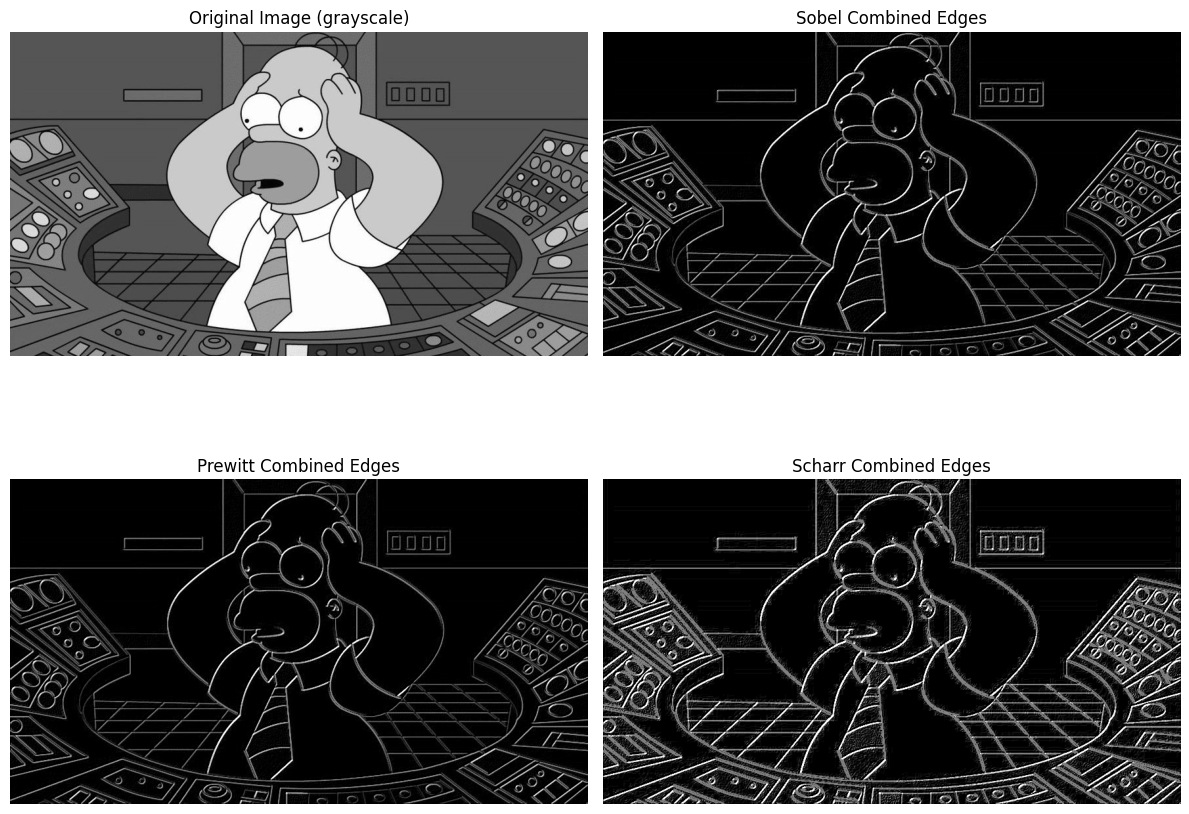

In [50]:
# Display results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Image (grayscale)')
axes[0, 0].axis('off')

axes[0, 1].imshow(sobel_combined_edges, cmap='gray')
axes[0, 1].set_title('Sobel Combined Edges')
axes[0, 1].axis('off')

axes[1, 0].imshow(prewitt_combined_edges, cmap='gray')
axes[1, 0].set_title('Prewitt Combined Edges')
axes[1, 0].axis('off')

axes[1, 1].imshow(scharr_combined_edges, cmap='gray')
axes[1, 1].set_title('Scharr Combined Edges')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

#### Canny Edge Detection

In [51]:
def apply_canny_edge_detection(img, threshold_pairs):

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(img, (5, 5), 1.4)
    
    # Prepare figure
    num_pairs = len(threshold_pairs)
    cols = 2
    rows = (num_pairs + 1) // 2  # +1 for the original image

    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    axes = axes.flatten()

    # Show original image
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Apply Canny edge detection for each threshold pair
    for i, (low, high) in enumerate(threshold_pairs):
        edges = cv2.Canny(blurred, low, high)
        axes[i + 1].imshow(edges, cmap='gray')
        axes[i + 1].set_title(f'Canny (Threshold: {low}-{high})')
        axes[i + 1].axis('off')


    plt.tight_layout()
    plt.show()


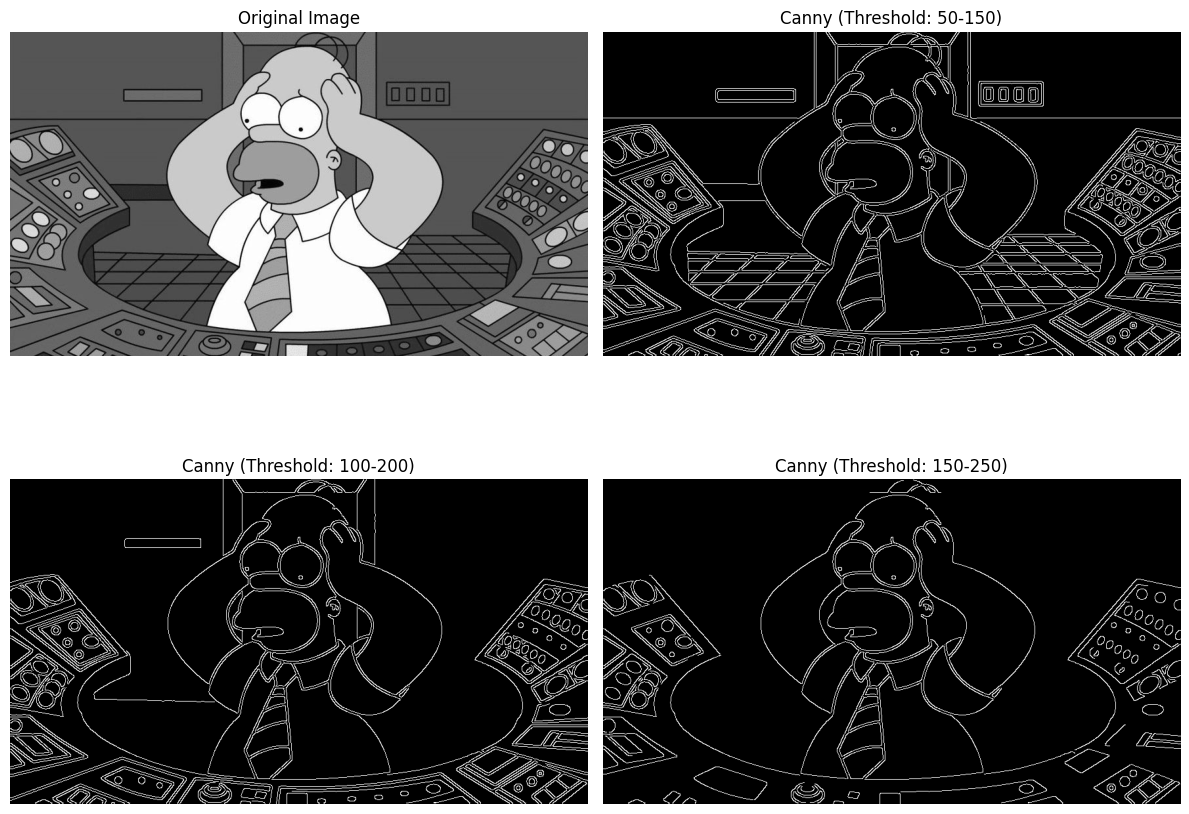

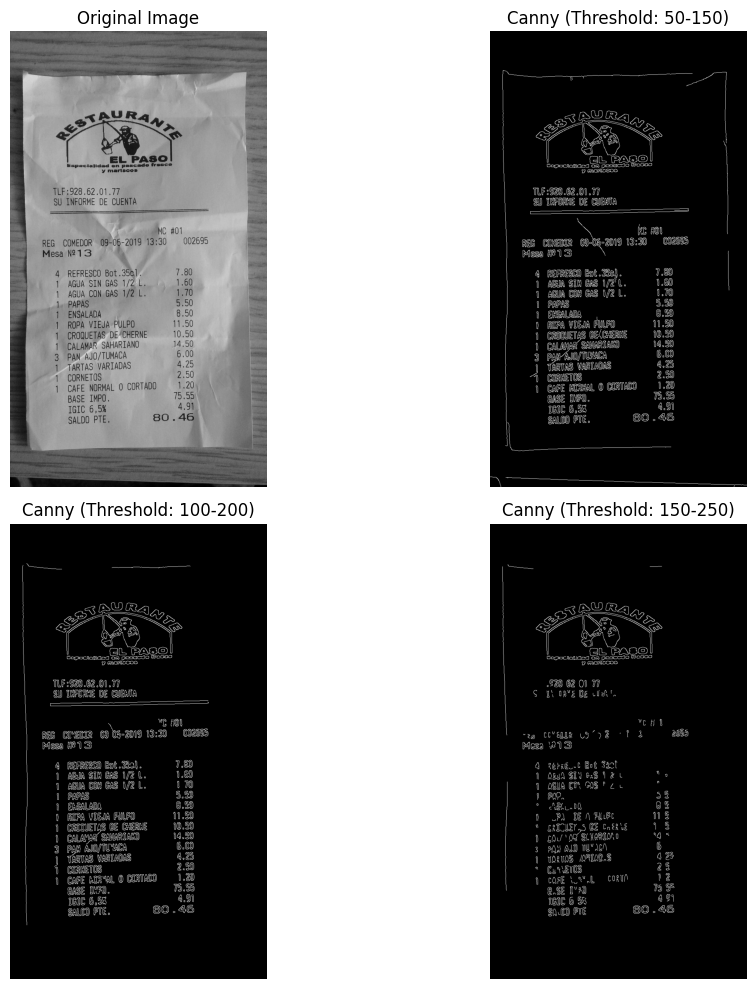

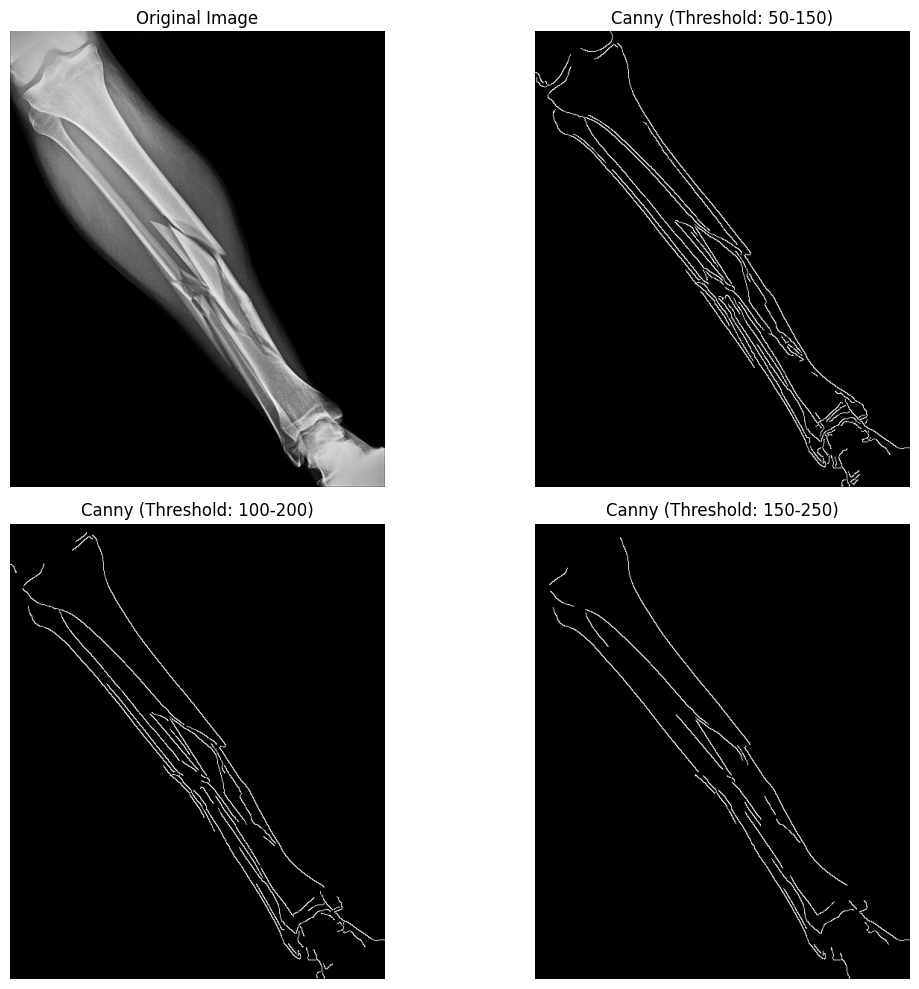

In [52]:
thresholds = [(50, 150), (100, 200), (150, 250)]

apply_canny_edge_detection(img, thresholds)
apply_canny_edge_detection(ticket_img, thresholds)
apply_canny_edge_detection(leg_img, thresholds)

#### Edge detection insights
Canny edge detector was usefult to to extract the main structural components of the images. This method allowed to detect edges and m inimized noise, which allowed to find silouhettes on the image. For instance, in the homer simpson image, we could find the silouhette of the character, the table and the floor.

#### Insights on thresholds.
The two thresholds in the Canny algorithm had a noticeable impact on the outcome. The high threshold ensured that only strong edges were clearly detected, while the low threshold allowed weaker edges to be included if they were connected to stronger ones. As both threshold increased, finer details were dismissed and only more clear edges were kept.

### Task 2: Corner Detection


In [53]:
def apply_harris_corner_detection(image_path):
    # Convert to grayscale and float32
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)

    # Harris Corner Detection with different parameters
    corner_detector1 = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)
    corner_detector2 = cv2.cornerHarris(gray, blockSize=4, ksize=5, k=0.04)
    corner_detector3 = cv2.cornerHarris(gray, blockSize=6, ksize=7, k=0.06)

    # Dilate corner image to enhance corner points
    corner_detector1 = cv2.dilate(corner_detector1, None)
    corner_detector2 = cv2.dilate(corner_detector2, None)
    corner_detector3 = cv2.dilate(corner_detector3, None)

    # Mark corners on copies of the image
    image1 = image.copy()
    image2 = image.copy()
    image3 = image.copy()
    image1[corner_detector1 > 0.01 * corner_detector1.max()] = [0, 0, 255]
    image2[corner_detector2 > 0.01 * corner_detector2.max()] = [0, 0, 255]
    image3[corner_detector3 > 0.01 * corner_detector3.max()] = [0, 0, 255]

    # Display with reduced figure size
    fig, axes = plt.subplots(2, 2, figsize=(8, 7))
    axes[0, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Original Image', fontsize=10, fontweight='bold')
    axes[0, 1].imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title('Harris Corner Detection\n(blockSize=2, ksize=3, k=0.04)', fontsize=9)
    axes[1, 0].imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title('Harris Corner Detection\n(blockSize=4, ksize=5, k=0.04)', fontsize=9)
    axes[1, 1].imshow(cv2.cvtColor(image3, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title('Harris Corner Detection\n(blockSize=6, ksize=7, k=0.06)', fontsize=9)

    # Remove axis ticks for cleaner display
    for ax in axes.flat:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

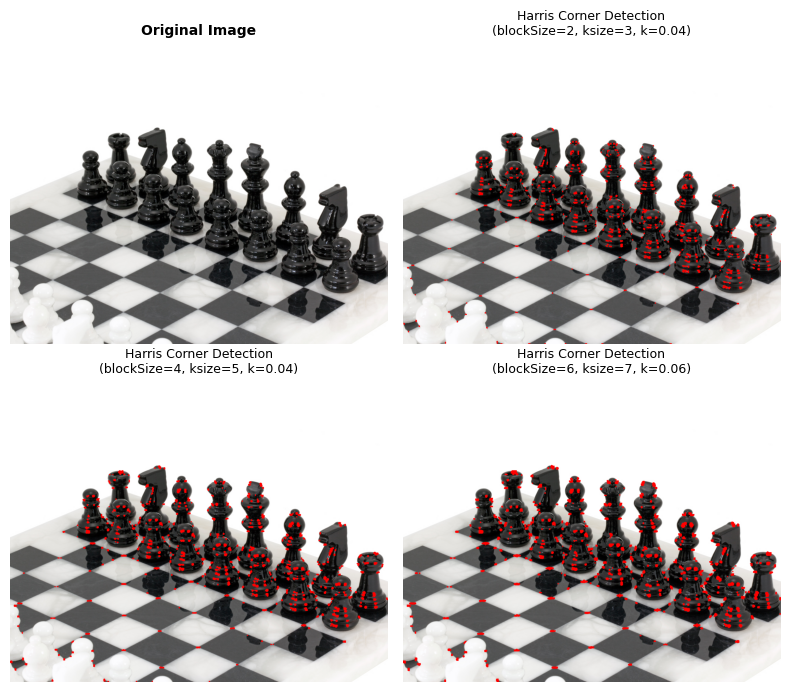

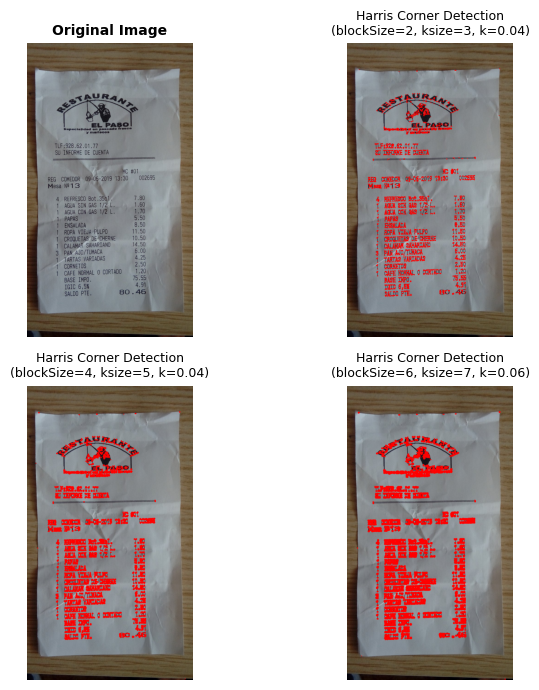

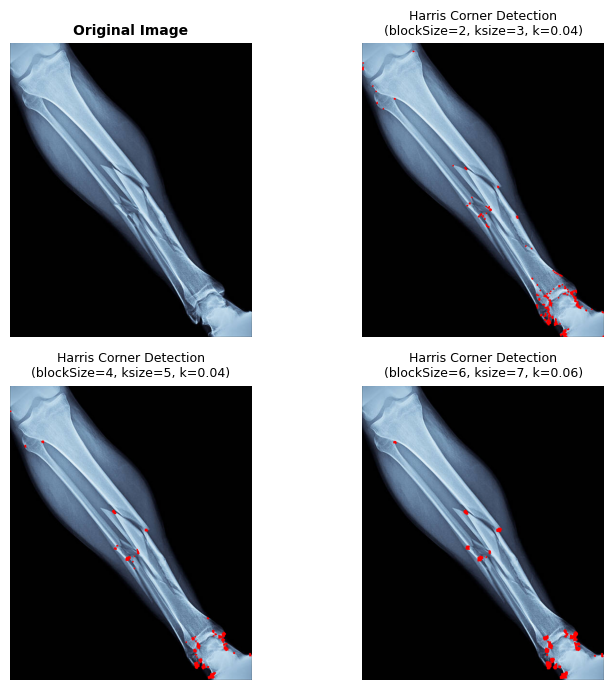

In [54]:
apply_harris_corner_detection(chess_img_path)
apply_harris_corner_detection(ticket_img_path)
apply_harris_corner_detection(leg_img_path)

#### Insights on applicability
We can see that in this case, the corner detection allow us to detect relevant points in the image that can be used for applications such as image stitching for panoramic image creation or 3D reconstruciton of images. However, by just picking and image and detecting the corners we can just see relevant points in the images. When we detected edges, we could obtain more structural components of the images such as in the restaurant ticket. In these previous examples, we could obtain relevant parts of the images, for instance, in the x ray, we could directly look at places where there are more corners which are regions of the image that are more probable to obtain relevant information.

#### Insights on Parameters
When it comes to the parameters, increasing the block size makes the algorithm look at a larger area around each pixel, which can detect broader features but may miss small details. A larger kernel size makes edge detection smoother but less sensitive to fine changes. Increasing the constant k makes the detector less sensitive, so fewer corners are found, while a smaller k makes it more sensitive and detects more corners, but also more noise. In this case, for each of these, we increased all 3 parameters, which detected more corners. This is mainly because the increase of block size, which makes the algorithm look at a larger area.

In [55]:
def apply_morphological_operations(image_path, kernel_size=(5,5), resize_dims=(300,300)):

    # Read the image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        print(f"Error: Could not load image from {image_path}")
        return
    
    # Resize the image
    image = cv2.resize(image, resize_dims)
    
    # Define the kernel
    kernel = np.ones(kernel_size, np.uint8)
    
    # Apply morphological operations
    eroded_image = cv2.erode(image, kernel, iterations=1)
    dilated_image = cv2.dilate(image, kernel, iterations=1)
    
    # Display the results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Original Image', fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    # Eroded image
    axes[1].imshow(eroded_image, cmap='gray')
    axes[1].set_title('Erosion', fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    # Dilated image
    axes[2].imshow(dilated_image, cmap='gray')
    axes[2].set_title('Dilation', fontsize=11, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

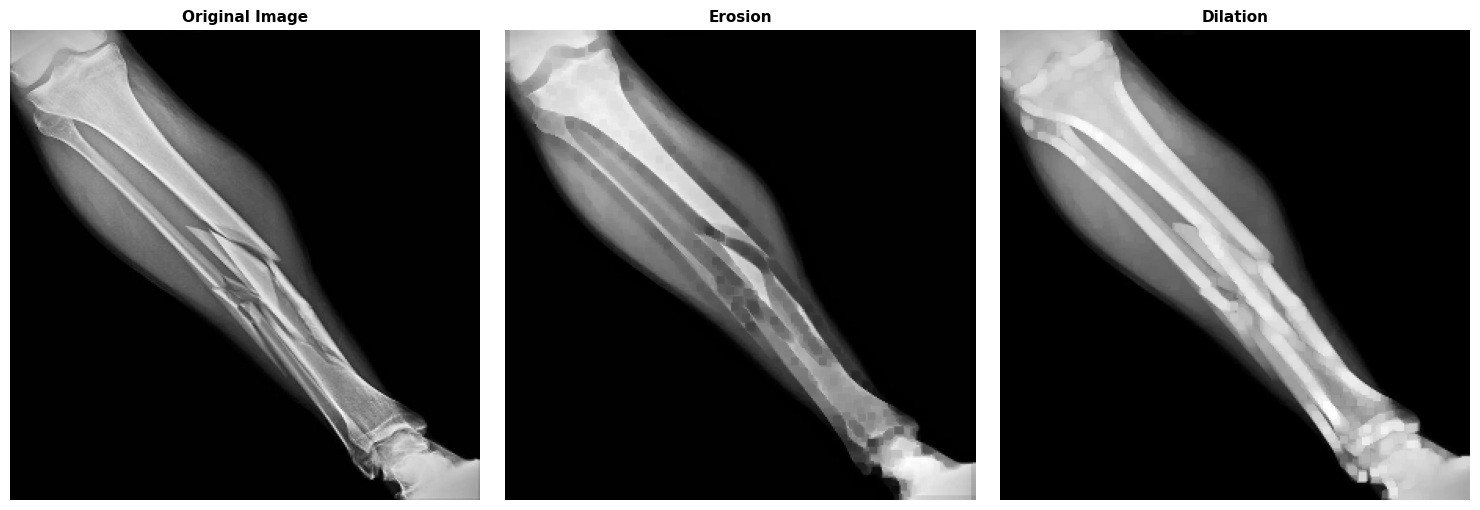

In [56]:
apply_morphological_operations(leg_img_path)

We can see that the example of the bone may not be a great case when it come to morphological operation. We can try using simpler shapes to see if it is more useful

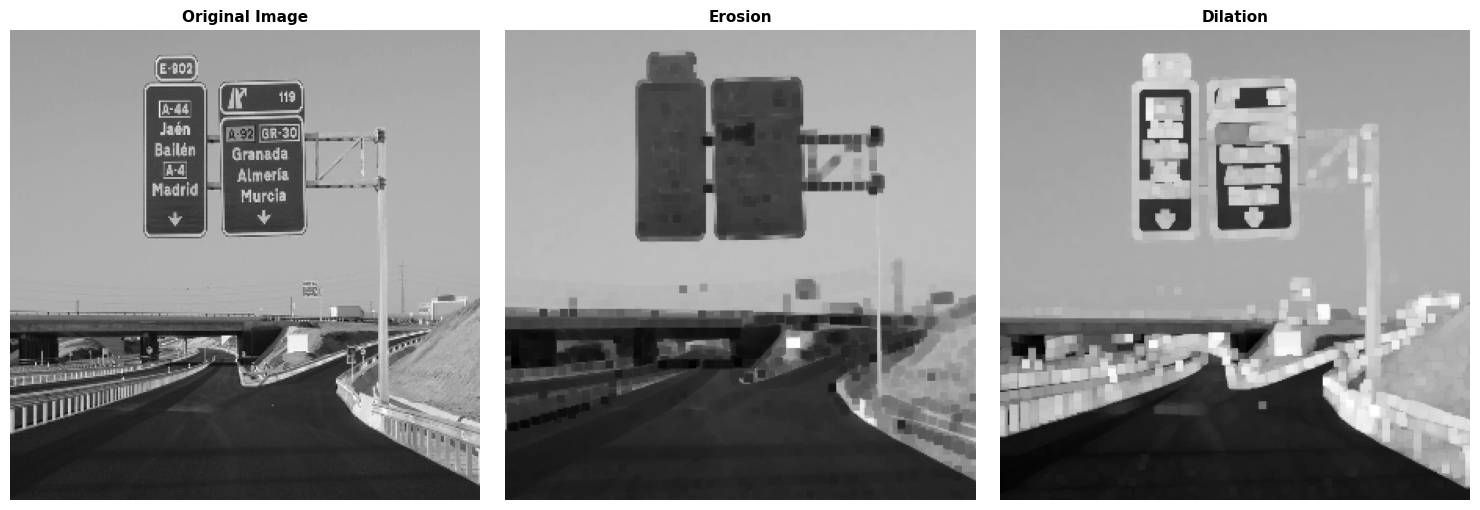

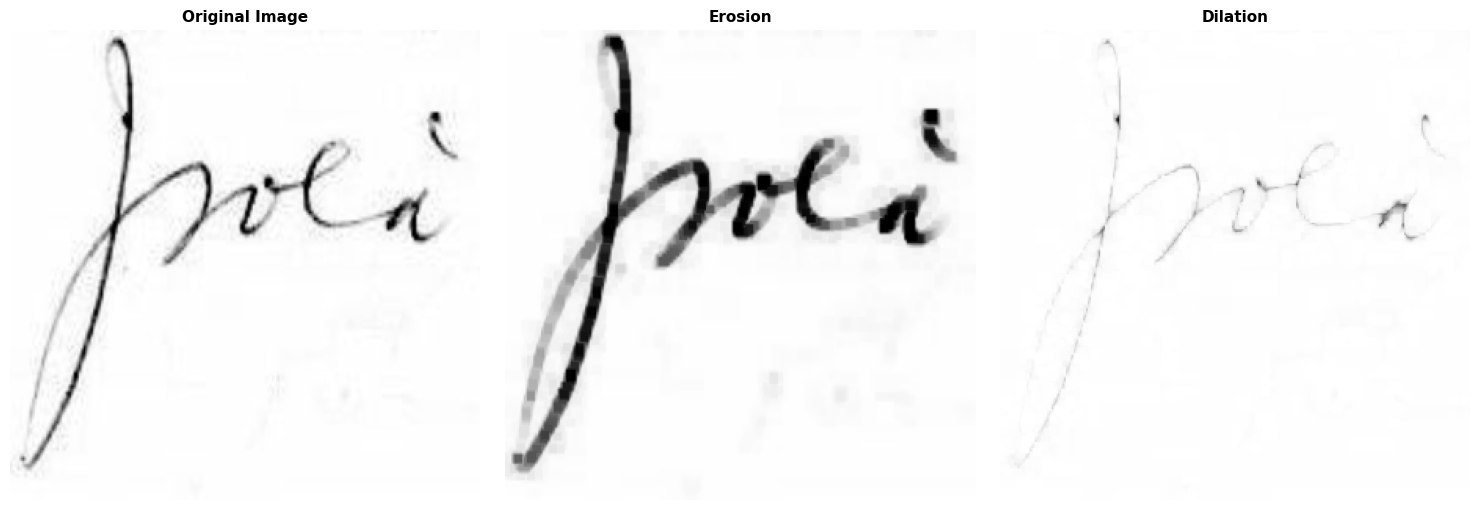

In [57]:
apply_morphological_operations(road_img_path)
apply_morphological_operations(signature_img_path)

With a road banner the letters are not seen with erotion or dilation, however, with the signature the application is better. I would say that both erosion and dilation are sueful, in the case of dilation we can see that finer details ar dismissed and just the more relevant parts of the signature are kept, while in the erotion we make the signautre bolder so that it can be seen better.

In [58]:
def apply_opening_closing(image_path, kernel_size=(9,9), resize_dims=(300,300)):

    # Read the image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        print(f"Error: Could not load image from {image_path}")
        return
    
    # Resize the image
    image = cv2.resize(image, resize_dims)
    
    # Define the kernel
    kernel = np.ones(kernel_size, np.uint8)
    
    # Apply morphological operations
    opened_image = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
    closed_image = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
    
    # Display the results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Add title with parameters
    fig.suptitle(f'Kernel Size: {kernel_size} | Image Size: {resize_dims}', 
                 fontsize=12, fontweight='bold', y=1.02)
    
    # Original image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Original Image', fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    # Opened image
    axes[1].imshow(opened_image, cmap='gray')
    axes[1].set_title('Opening', fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    # Closed image
    axes[2].imshow(closed_image, cmap='gray')
    axes[2].set_title('Closing', fontsize=11, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

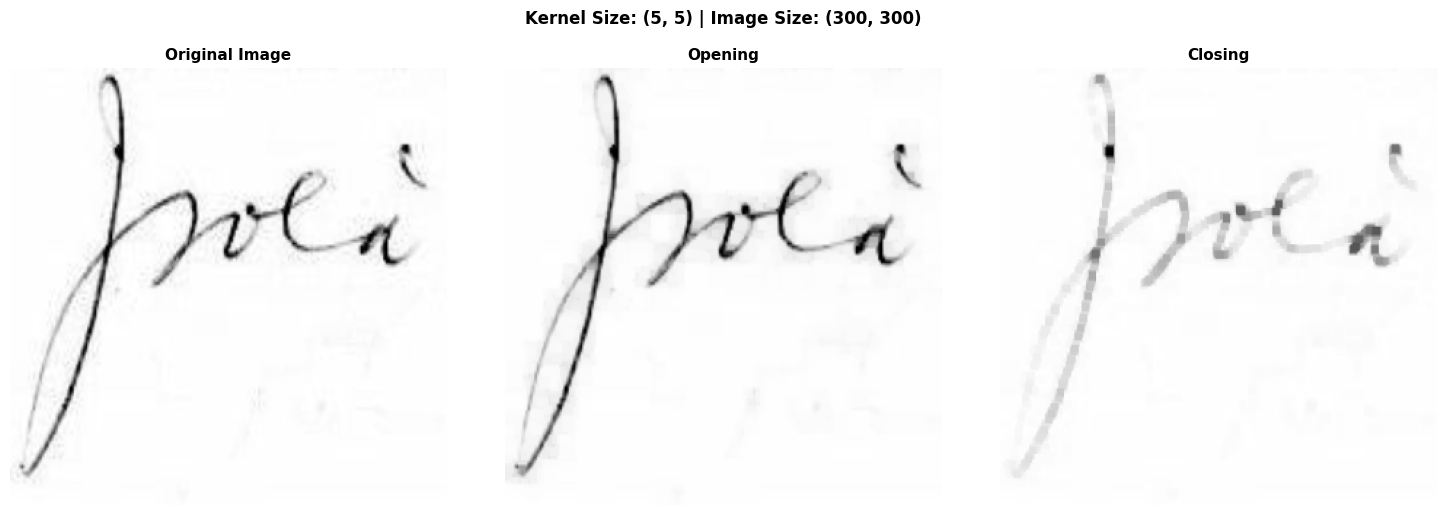

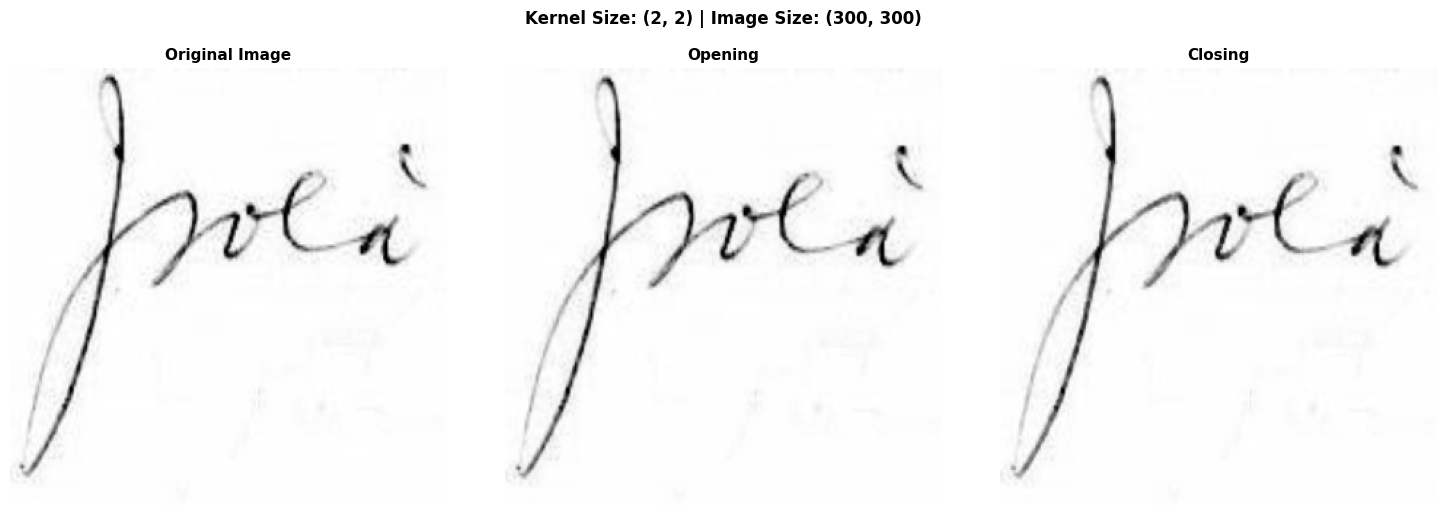

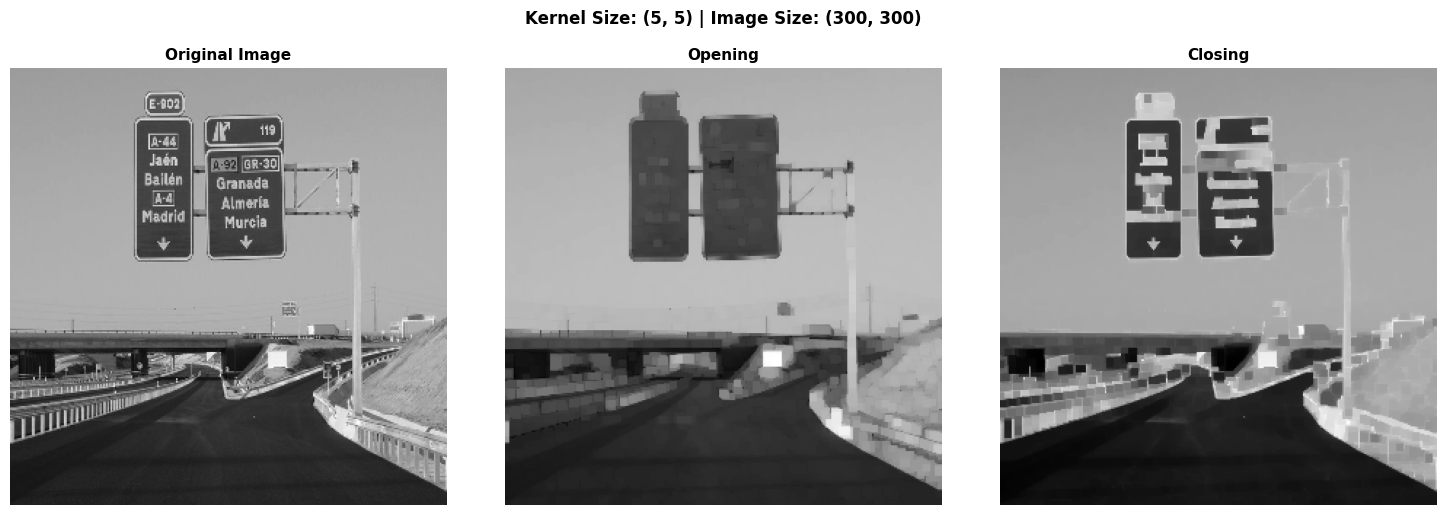

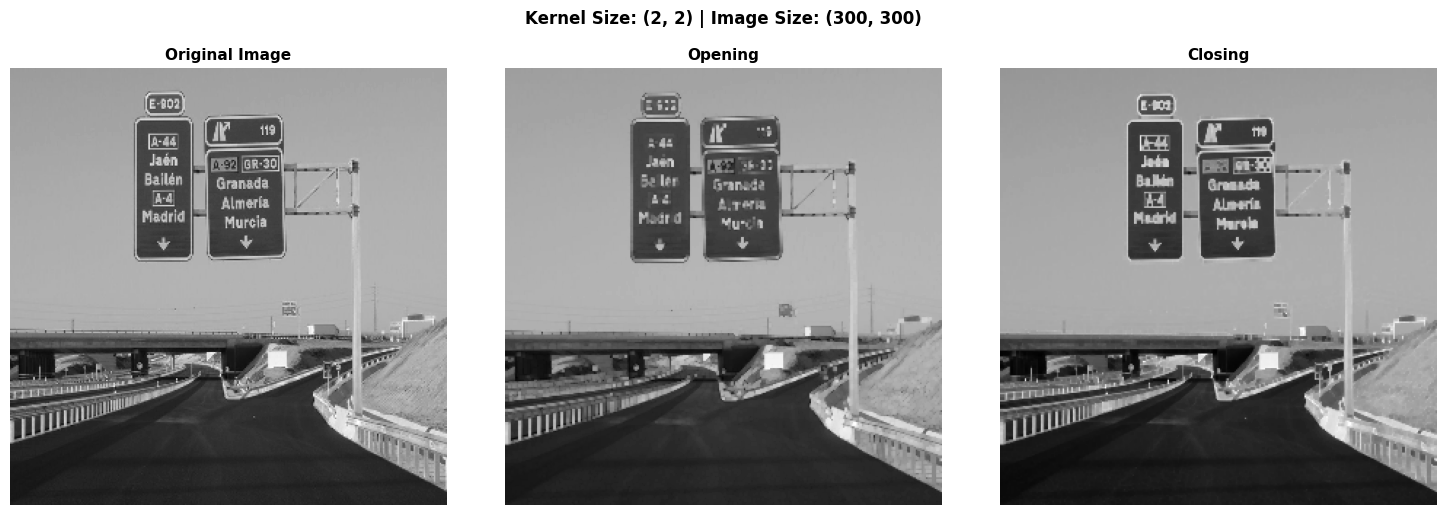

In [59]:
apply_opening_closing(signature_img_path, kernel_size=(5,5))
apply_opening_closing(signature_img_path, kernel_size=(2,2))
apply_opening_closing(road_img_path, kernel_size=(5,5))
apply_opening_closing(road_img_path, kernel_size=(2,2))

#### Insights on closing and opening
Finally I applied both a combinaiton of erosion and dilaiton in a closing and opening operators. I used different kernel sizes to see the outputs and results. In this case, the results were good, specially with lower kernel sizes (2,2), which allowed to obatain a less blurry image compared to higher kernels, and at the same time kept the most relevant information. In the case of the signature I would say that a combination of dilation and erosion with a proper selection of kernel size is a good technique to enhance the image and obtain a better result compared to the original signature as we slightly remove noise and at the same time keep the most relevant strucutre. 

However, with the road banner image, I would say it is not a great application as the result is a blurrier image which is more difficult to read, independently of the kernel size applied

In [60]:
def apply_morphological_gradient(image_path, kernel_size=(5,5), resize_dims=(300,300)):

    # Read the image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        print(f"Error: Could not load image from {image_path}")
        return
    
    # Resize the image
    image = cv2.resize(image, resize_dims)
    
    # Define the kernel
    kernel = np.ones(kernel_size, np.uint8)
    
    # Calculate the morphological gradient
    gradient_image = cv2.morphologyEx(image, cv2.MORPH_GRADIENT, kernel)
    
    # Display the results
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Add super title with parameters
    fig.suptitle(f'Kernel Size: {kernel_size} | Image Size: {resize_dims}', 
                 fontsize=12, fontweight='bold', y=1.02)
    
    # Original image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Original Image', fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    # Gradient image
    axes[1].imshow(gradient_image, cmap='gray')
    axes[1].set_title('Morphological Gradient', fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

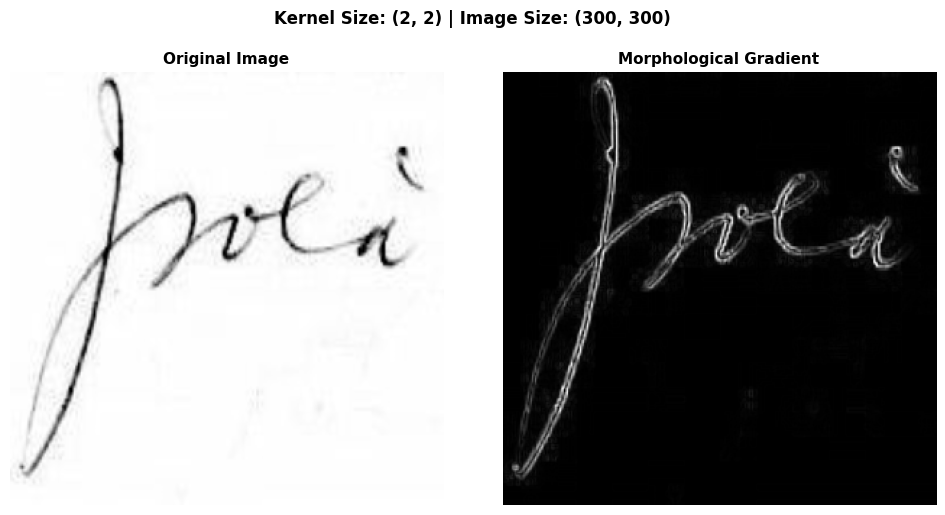

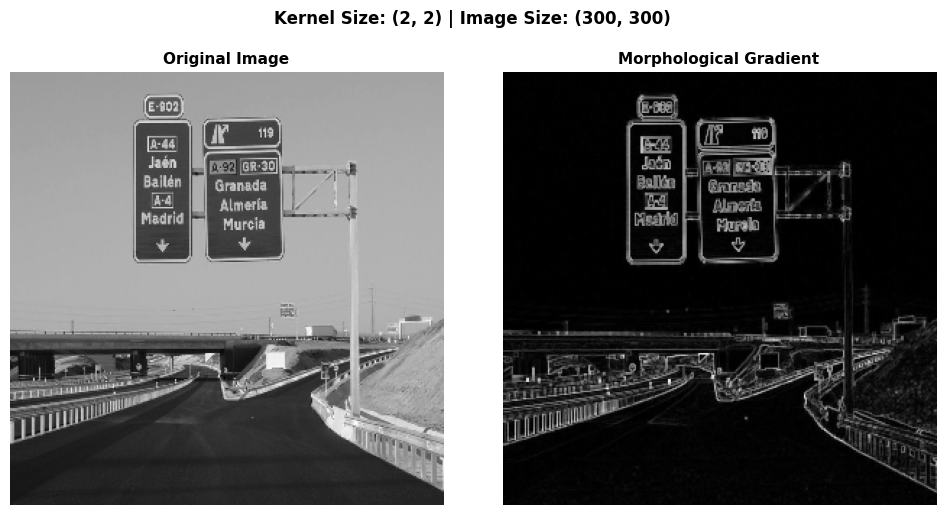

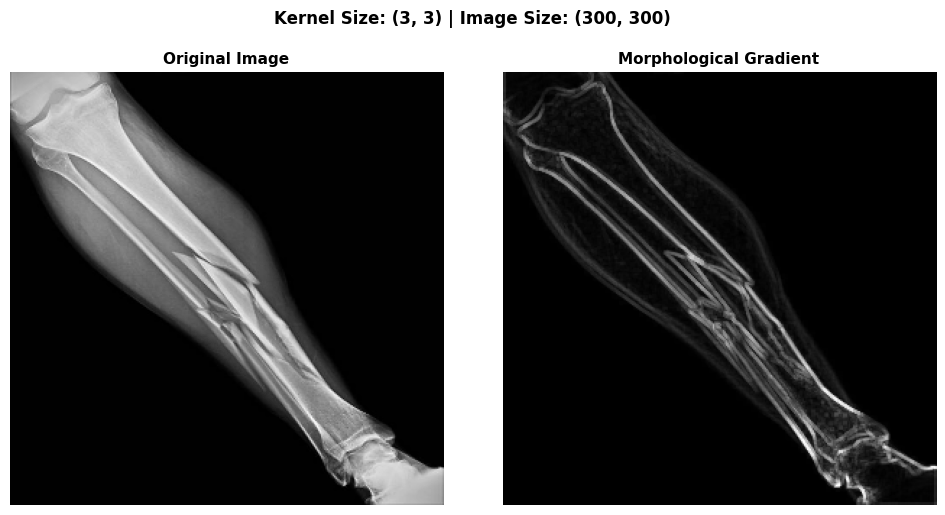

In [61]:
apply_morphological_gradient(signature_img_path, kernel_size=(2,2))
apply_morphological_gradient(road_img_path, kernel_size=(2,2))
apply_morphological_gradient(leg_img_path, kernel_size=(3,3))  

#### Analysis on Morphological Gradient
At the end, I also applied a morphological gradient to different images, which is the difference between dilaiton and erosion. With the images of the road and the signature the result may not be ideal, as the result is blurry and I would say that more confusing to interpret as the original image. However, it may have some applicability to the medical field, where an x-ray is better seen as most relevant parts of the structure are visible, and least important parts are dismissed. It is important to note that the proper selection of a kernel size it is relevant to obtain a desired result here. 